# Machine Learning Notes

This file contains notes for machine learning.

## Features and Labels

- **Features** are the inputs provided to the machine for processing.
- **Labels** are the outputs given by the machine after processing features.

---

## Supervised and Unsupervised learning

- **Supervised Learning** is the term used for the data which is already processed by the machine or in other words, something that machine knows before hand. Feature and labels are already present on the data. It contains:-

  - **Classification** : It refers to the mode where model performs classification on the basis of pre-defined labels.

  - **Regression** : It refers to prediction of values on basis of historical data.

- **Unsupervised learning** is the term used for the data which is new for the machine. Neither it has any features or labels present on it nor the machine is trained for it. It contains:-

  - **Clustering** : When the model is asked to perform classification on the basis of features only.

---

We'll use **Python** for machine learning since it has already developed libraries like ***scikit-learn(sklearn)***

---

Most of the material in this file is incorporated from [Microsoft Learn repository](https://github.com/MicrosoftDocs/ml-basics/)

Machine Learning requires data on which it can operate. For notes,we're using the [Flights Challenge](/assets/flights.csv)'s data.

In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as mp

To import a .csv file, we use **`read_csv("filepath")`** function of *Pandas* library. It returns a dataframe which has values imported from csv file.

In [2]:
data = pd.read_csv("d:/Projects/ML/assets/flights.csv")
data.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


## Data Analysis
### Data Cleaning - Handling null values
Now we have our data, the first step is to clean data. <br>Data can be cleaned in two steps:
1. **Fill null values** - We can fill up the null values in our data with the values of our wish.
Firstly let's check for null values:

In [3]:
data.isnull().sum()

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64

To fill this data:<br>We use **`fillna(value_to_be_filled_with)`** function.

In [4]:
# I have commented the line since I don't prefer filling null values.
# data.DepDel15 = data.DepDel15.fillna(data.DepDel15.mean())

2. **Removing null values** *(which I prefer)* - We can remove the null values present in our data. In most cases, it's better to remove null values and train our model on the data which is absolutely correct. This also improves its *MSE* and *RMSE*.<br>
To remove the null values from ***DepDel15*** column,<br>We use **`dropna(axis=?,how=?)`**

In [5]:
data = data.dropna(axis=0,how='any')
data.isnull().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
Carrier              0
OriginAirportID      0
OriginAirportName    0
OriginCity           0
OriginState          0
DestAirportID        0
DestAirportName      0
DestCity             0
DestState            0
CRSDepTime           0
DepDelay             0
DepDel15             0
CRSArrTime           0
ArrDelay             0
ArrDel15             0
Cancelled            0
dtype: int64

### Outlier Handling<br>

Now that we have cleaned our data, next step is to remove outliers. For that we first have to determine the distribution and its density.

---
For determinig distribution, we have to use our ***matplotlib.pyplot*** library.

In [6]:
# We'll define a function for viewing distribution
def distribution(var):
    import matplotlib.pyplot as mp
    %matplotlib inline
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    print("Mean : {0}\nMedian: {1}\nMode: {2}\nMin: {3}\nMax: {4}".format(mean,median,mode,min,max))
    fig,ax = mp.subplots(2, 1,figsize=(9,6))
    ax[0].hist(x=var)
    ax[0].axvline(x=mean, color='red',linewidth=3)
    ax[0].axvline(x=median, color='green',linewidth=3)
    ax[0].axvline(x=mode, color='black',linewidth=3)
    ax[0].axvline(x=min, color='yellow',linewidth=3)
    ax[0].axvline(x=max, color='purple',linewidth=3)

    ax[1] = mp.boxplot(x=var,vert=False)
    fig.suptitle("Distribution of data")
    fig.show(warn=False)

The **Distribution** function will help us determine the distribution of the variable provided to it.
Its explaination is given below:
1. First we import the **`matplotlib.pyplot`** library. The `%matplotlib imline` statement aligns the plots inline in the notebook.
2. Then we assign variables to the statistical data of our variable like *mean, median, mode, etc.* and print them for further usage. The `format()` function allows us to interpolate variable between the string.
3. After that, we create a figure with 1 row and 2 columns and name it as *fig* and assign its axes to *ax*.
4. On the first column, we create a histogram and plot mean, median,mode on it. The `axvline()` function plots a 2D line on the graph.
5. Then on the 2nd column, we will plot a boxplot graph. A boxplot graph is useful for determining outliers as it creates a circle on the values which occur outside the usual ones.
6. After plotting graphs, we wil use `suptitle` to title our graphs and `show` function to save our graphs.

---

Now that we have created our function, we will now see the distribution of **DepDelay** column

Mean : 10.456614371849216
Median: -1.0
Mode: -3
Min: -63
Max: 1425


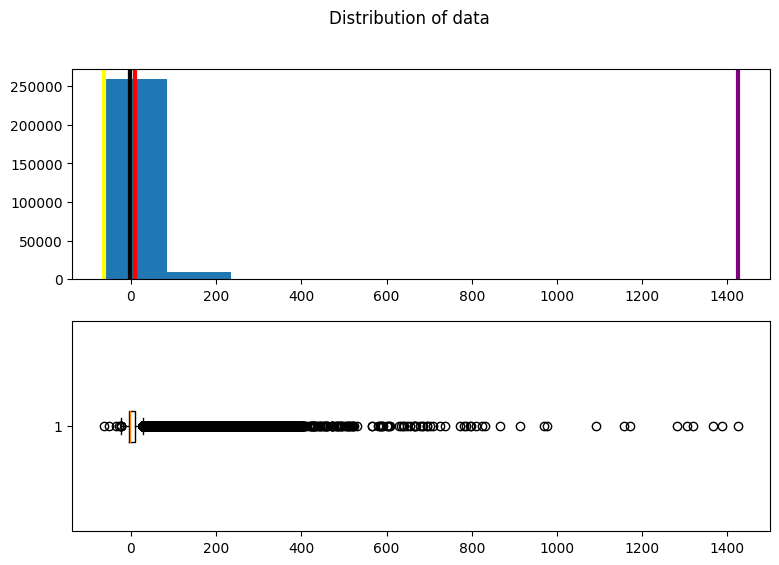

In [7]:
Dep_delay = data['DepDelay']
distribution(Dep_delay)

**Removing Outliers** - 
This data is quite uneven according to our histogram and it also has a good number of outliers according to our boxplot graph. So, let's start removing them.<br>
We'll use the `quantile` function of *pandas* library to remove our outliers.

Mean : 2.455424304018821
Median: -1.0
Mode: -3
Min: -7
Max: 37


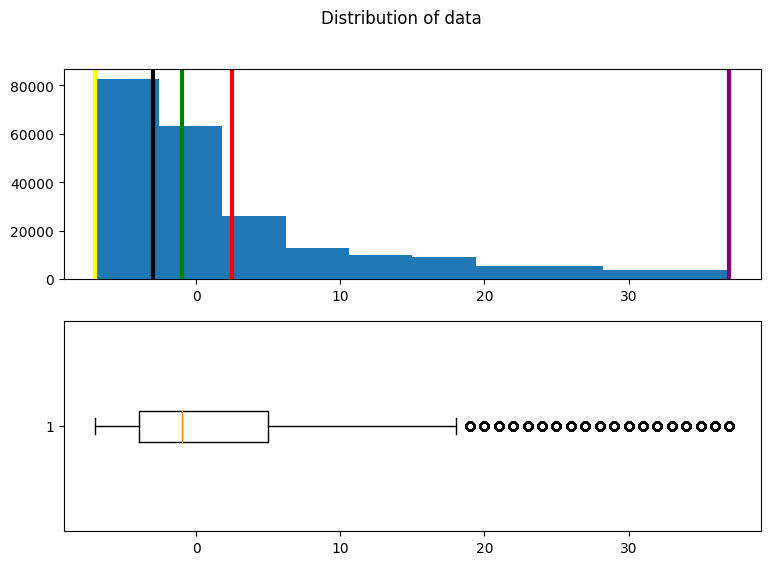

In [8]:
Dep_out = Dep_delay.quantile(0.9)
Dep_in = Dep_delay.quantile(0.1)
Dep_delay = Dep_delay[Dep_delay.between(Dep_in, Dep_out)]
distribution(Dep_delay)

**`Quantile`** function helps us to remove outliers present in our data. In the previous cell,On the line 1,I added the quantile function with a parameter of 0.9 which take the values above the 90% and assigns it to a variable **Dep_out**. On the 2nd line, I added the quantile function with the parameter of 0.1 which takes the values below 10% and assigns it to a variable **Dep_in**.

---

Now that the *DepDelay* column is clean, let's start cleaning *ArrDelay* column.

In [9]:
Arr_Delay = data['ArrDelay']
Arr_out = Arr_Delay.quantile(0.9)
Arr_in = Arr_Delay.quantile(0.1)
Arr_Delay = Arr_Delay[Arr_Delay.between(Arr_out,Arr_in)]

We have cleared ***Arr_Delay*** and ***Dep_Delay*** columns which are our labels on which we'll be building our models.

---

### Density Plot

Another way of visualizing data is by plotting its density. *Pandas* library has a useful and effective way to do this.

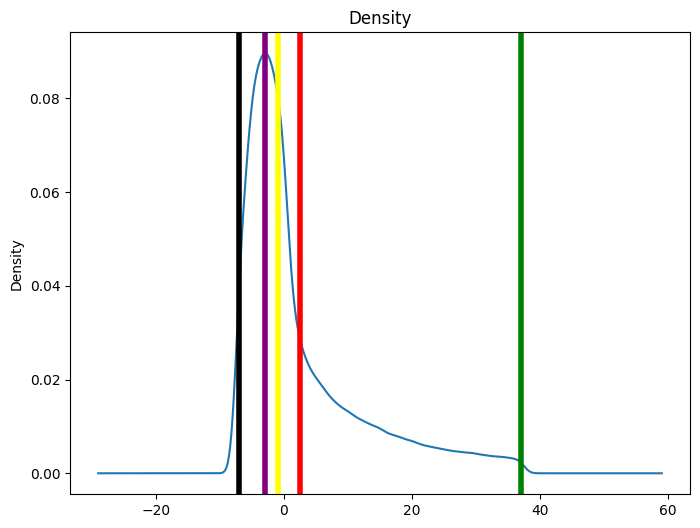

In [10]:
def density(var):
    import matplotlib.pyplot as mp
    fig = mp.figure(figsize=(8,6)) # Figure function is same as subplots but it creates only a single figure
    var.plot.density() # Plotting density
    mp.title("Density")
    mean = var.mean()
    median = var.median()
    mode = var.mode()[0]
    max = var.max()
    min = var.min()
    mp.axvline(x=mean,color='red',linewidth=4)
    mp.axvline(x=median,color='yellow',linewidth=4)
    mp.axvline(x=max,color='green',linewidth=4)
    mp.axvline(x=min,color='black',linewidth=4)
    mp.axvline(x=mode,color='purple',linewidth=4)
    mp.show()

density(Dep_delay)

### Standard Deviation and Variance

Variance is an important concept in statistical analysis of data. In python, there are pre-defined functions which help us calculate the standard and mean deviation of our data.

---

**Standard and Mean deviation** - What is the difference?
While they both tell the deviation of data from its mean, their calculation is a bit different.

*The **mean deviation** is calculated by subtracting mean from each value and taking average of the difference, while **standard deviation** is calculated by the root of **variance** which in turn is calculated by the squared difference between mean and values.*

Since *standard deviation* uses squared values, it is more sensitive to **outliers**.

---

**Calculating variance and standard deviation in *Python***

In [11]:
std = Dep_delay.std()
var = Dep_delay.var()
print("Standard deviation: {0}\nVariance: {1}\n".format(std,var))

Standard deviation: 9.555299888938341
Variance: 91.30375596754507



We can also use **`describe`** function. It is a more useful function as it provides all the useful information required to analyze our data.

In [12]:
data.describe(exclude=[object])
#exclude argument takes a list of types which should not be included while calculating mean,variance,etc.

,Year,Month,DayofMonth,DayOfWeek,OriginAirportID,DestAirportID,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
count,269179.0,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000,269179.000000
mean,2013.0,6.983877,15.817259,3.902336,12744.767642,12739.446093,1324.412933,10.456614,0.201134,1504.637338,6.563287,0.207888,0.000576
std,0.0,1.983873,8.805963,1.989296,1501.949045,1503.506863,470.760511,35.840715,0.400849,493.215438,38.420207,0.405797,0.023989
min,2013.0,4.000000,1.000000,1.000000,10140.000000,10140.000000,1.000000,-63.000000,0.000000,1.000000,-75.000000,0.000000,0.000000
25%,2013.0,5.000000,8.000000,2.000000,11292.000000,11292.000000,920.000000,-4.000000,0.000000,1119.000000,-11.000000,0.000000,0.000000
50%,2013.0,7.000000,16.000000,4.000000,12892.000000,12892.000000,1319.000000,-1.000000,0.000000,1527.000000,-3.000000,0.000000,0.000000
75%,2013.0,9.000000,23.000000,6.000000,14057.000000,14057.000000,1722.000000,9.000000,0.000000,1917.000000,10.000000,0.000000,0.000000
max,2013.0,10.000000,31.000000,7.000000,15376.000000,15376.000000,2359.000000,1425.000000,1.000000,2359.000000,1440.000000,1.000000,1.000000


With this, We Complete our Data Analysis part. But it is hard to maintain low ***MSE*** and ***RMSE*** without normalizing it. So, let's start normalizing our data.

---

### Normalizing Data

It is important to normalize data especially numeric values so that they are always measured on the same scale. This helps our model to easily find out *correlation* between them. For this, we are going to use **sklearn** Library.

Our columns of interest(*ArrDelay* and *DepDelay*) are already normalized, so we don't need to change it. So
we'll leave it as it is.

In [13]:
# from sklearn.preprocessing import MinMaxScaler

# Get a scaler object
# scaler = MinMaxScaler()

# Create a new dataframe for the scaled values
# df_normalized = df_sample[['Name', 'Grade', 'StudyHours']].copy()

# Normalize the numeric columns
# df_normalized[['Grade','StudyHours']] = scaler.fit_transform(df_normalized[['Grade','StudyHours']])

# Plot the normalized values
# df_normalized.plot(x='Name', y=['Grade','StudyHours'], kind='bar', figsize=(8,5))

### Finding Correlation

Let's find correlation betweeen our data by using **`corr()`** function.

In [14]:
data.DepDelay.corr(data.ArrDelay)

0.9388604387910373

Correlation is a statistic value that shows the *strength of relationship* between two data. its value is b/w 1 & -1. In our case, the **corr()** function returns a value of 0.94 (approx) which means that *DepDelay* and *ArrDelay* have a strong relationship.
> WARNING: data scientist often use quote - ***correlation is not the causation*** which means here that high correlation value does not indicate higher departure delays have high arrival delays or vice versa.

---

***Visualising Correlation***:<br>
we can use a scatter plot to demonstrate the correlation between our data.

<Axes: xlabel='DepDelay', ylabel='ArrDelay'>

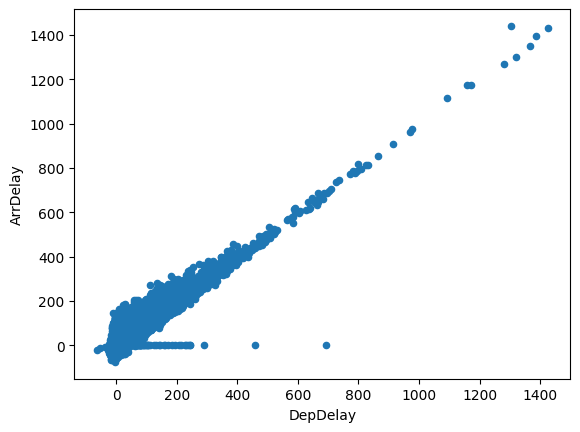

In [15]:
data.plot.scatter(x='DepDelay', y='ArrDelay')

## Training a Regression Model

Now that we have analyzed what data has been given to us, let's start making a Regression Model out of it.
For that we'll move step by step.

1. Plot a regression line
2. Find out what label is to be predicted
3. Separate features into numeric and categorical features
4. Split training and testing data
5. Find out the model's MSE, RMSE, r2_score
6. Test model using different algorithms
7. Optimize model's hyperparameters